# Structural robustness of mammalian transcription factor networks reveals plasticity across development

## Human Analysis

#### External imports

In [1]:
import os
import pandas as pd
from io import BytesIO
import networkx as nx
from PIL import Image
import inspect
import numpy as np
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from itertools import chain
import re
import time
import random

#### Auxiliar Fxns

In [2]:
def get_human_names(root, code_names):
    name = re.split('buffer.5000', root)
    name = name[1]
    name = name.replace('\\','')
    return code_names[name]

In [3]:
def extract_networks(directory_name=str, files_ignore=list, cols=tuple, feo=True, code_names=dict):
    networks = {}
    for root, dir, files in os.walk(directory_name):
        if len(files) != 0 and files[0] not in files_ignore:
          path = os.path.join(os.getcwd(), root, files[0])
          net = nx.DiGraph()
          name = get_human_names(root, code_names)
          if feo:
               f = np.genfromtxt(path, dtype= str, delimiter='\t', usecols= cols)
               net.add_edges_from(f)
          else:
               net = nx.read_edgelist(path, create_using= nx.DiGraph)
          
          networks[name] = net
    return networks

#### Biological Networks

In [4]:
hg19CellTypeValues = { "AG10803-DS12374" : "skin fibroblast (abdomen)",
"AoAF-DS13513" : "aortic adventitial fibroblast",
"CD20-DS18208" : "B-cells (CD20+)",
"CD34-DS12274" : "Hematopoietic stem/progenitor cells (CD34+)",
"fBrain-DS11872" : "fetal brain",
"fHeart-DS12531" : "fetal heart",
"fLung-DS14724" : "fetal lung",
"GM06990-DS7748" : "B-lymphoblastoid cells (individual 06990)",
"GM12865-DS12436" : "B-lymphoblastoid cells (individual 12865)",
"HAEpiC-DS12663" : "amniotic epithelium",
"HAh-DS15192" : "hippocampal astrocyte",
"HCF-DS12501" : "cardiac fibroblast",
"HCM-DS12599" : "cardiac myocyte",
"HCPEpiC-DS12447" : "choroid plexus epithelium",
"HEEpiC-DS12763" : "esophageal epithelium",
"HepG2-DS7764" : "hepatic (hepatoblastoma)",
"hESCT0-DS11909": "embryonic stem cells (line H7)",
"HFF-DS15115" : "foreskin fibroblast",
"HIPEpiC-DS12684" : "iris pigment epithelium",
"HMF-DS13368" : "mammary fibroblast",
"HMVEC_dBlAd-DS13337" : "microvascular endothelium, adult, blood",
"HMVEC_dBlNeo-DS13242" : "microvascular endothelium, neonatal, blood",
"HMVEC_dLyNeo-DS13150" : "microvascular endothelium, neonatal, lympathic",
"HMVEC_LLy-DS13185" : "microvascular endothelium, lung-derived",
"HPAF-DS13411" : "pulmonary artery fibroblast",
"HPdLF-DS13573" : "periodontal ligament fibroblast",
"HPF-DS13390" : "pulmonary fibroblast",
"HRCE-DS10666" : "renal cortical epithelium",
"HSMM-DS14426" : "skeletal muscle myoblast",
"hTH1-DS7840" : "Th1 T-cells",
"HVMF-DS13981" : "villous mesenchymal fibroblast",
"IMR90-DS13219" : "pulmonary fibroblast, fetal",
"K562-DS9767" : "erythroid (erythroleukemia)",
"NB4-DS12543" : "granulocytic (promyelocytic leukemia)",
"NHA-DS12800" : "astrocyte",
"NHDF_Ad-DS12863" : "dermal fibroblast, adult",
"NHDF_Neo-DS11923" : "dermal fibroblast, neonatal",
"NHLF-DS12829" : "lung fibroblast",
"SAEC-DS10518" : "small airway epithelium",
"SkMC-DS11949" : "skeletal myocytes",
"SKNSH-DS8482" : "neuroblastoid (neuroblastoma)"
}

human_networks = extract_networks('g:\\Mi unidad\\Respaldo\\Genomicas\\netective\\data\\human_net', [], (0,1), feo=False, code_names=hg19CellTypeValues)

In [7]:
test = {
    i : j 
    for k, i in enumerate(human_networks.keys())
    for j in human_networks.values()
    if k < 5
}
test

{'aortic adventitial fibroblast': <networkx.classes.digraph.DiGraph at 0x2536dd81370>,
 'B-cells (CD20+)': <networkx.classes.digraph.DiGraph at 0x2536dd81370>,
 'Hematopoietic stem/progenitor cells (CD34+)': <networkx.classes.digraph.DiGraph at 0x2536dd81370>,
 'fetal brain': <networkx.classes.digraph.DiGraph at 0x2536dd81370>,
 'fetal heart': <networkx.classes.digraph.DiGraph at 0x2536dd81370>}

In [5]:
test_1 = {
    i : nx.convert_node_labels_to_integers(j) 
    for k, i in enumerate(human_networks.keys())
    for j in human_networks.values()
    if k < 5
}
test_1

{'aortic adventitial fibroblast': <networkx.classes.digraph.DiGraph at 0x1983b878100>,
 'B-cells (CD20+)': <networkx.classes.digraph.DiGraph at 0x1983b80dac0>,
 'Hematopoietic stem/progenitor cells (CD34+)': <networkx.classes.digraph.DiGraph at 0x1983b80dc70>,
 'fetal brain': <networkx.classes.digraph.DiGraph at 0x1983b878220>,
 'fetal heart': <networkx.classes.digraph.DiGraph at 0x19841bc4eb0>}

In [32]:
for i, j in test_1.items():
    name = i.replace('/', '_')
    nx.write_edgelist(j, path=f'{name}', delimiter='\t', encoding='utf-8', data=False)

#### Synthetic networks

ER and BA analogous ensembles to each biological network.

In [14]:
from freyrelab.nets import models

seed = 42
synth_graphs = {}

for net_id, G in test.items():
    n = G.number_of_nodes()
    m = G.number_of_edges()
    for i in range(1,2):
        synth_graphs[f'BA_{net_id}_{i}'] = models.barabasi_albert_graph(n)
        synth_graphs[f'ER_{net_id}_{i}'] = nx.erdos_renyi_graph(n, m/(n*(n-1)), seed=seed, directed=True)

networks = {**test, **synth_graphs}

In [16]:
isinstance(networks['BA_aortic adventitial fibroblast_1'], nx.Graph)

True

#### Graphs overall info

In [11]:
nets_info = {'Cell Type': [],
        'Nodes': [],
        'Edges': [],
        'Density': []
        }

for name,G in networks.items():
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    density = n_edges / (n_nodes * (n_nodes - 1))
    nets_info['Cell Type'].append(name)
    nets_info['Nodes'].append(n_nodes)
    nets_info['Edges'].append(n_edges)
    nets_info['Density'].append(density)

info_df = pd.DataFrame.from_dict(nets_info)
info_df

,Cell Type,Nodes,Edges,Density
0,aortic adventitial fibroblast,521,12482,0.046073
1,B-cells (CD20+),521,12482,0.046073
2,Hematopoietic stem/progenitor cells (CD34+),521,12482,0.046073
3,fetal brain,521,12482,0.046073
4,fetal heart,521,12482,0.046073
5,BA_aortic adventitial fibroblast_1,521,2064,0.007618
6,ER_aortic adventitial fibroblast_1,521,12316,0.045460
7,BA_B-cells (CD20+)_1,521,2050,0.007567
8,ER_B-cells (CD20+)_1,521,12316,0.045460
9,BA_Hematopoietic stem/progenitor cells (CD34+)_1,521,2050,0.007567


### Netective Analysis

In [12]:
from netective import compare_structure
from netective import characterize_network

Properties used for analysis: 
Average Clustering Coefficient
Average Degree for Nearest Neighbors (Undirected)
Average Local Efficiency
Average Degree for Nearest Neighbors (Out-Out)
Average Shortest Path Length
Betweenness Centrality
Center
Clustering Coefficient
Complex Feed-Forward Circuits
Density
Diameter
Eccentricity
Entropy of Degree Distribution
3-Feedback Loops
Gene % in the Giant Component
Gini Index
Global Efficiency
In-Degree
Locality Index
Max In-Dregree
Max Out-Degree
Out-Degree
Periphery
Radius
Regulators
Rich Club Coefficient
Self-Regulations
Subgraph Centrality


Average Degree for Nearest Neighbors (Out-Out) cannot be computed for the input graph.
Complex Feed-Forward Circuits cannot be computed for the input graph.
3-Feedback Loops cannot be computed for the input graph.
Density cannot be computed for the input graph.
Entropy of Degree Distribution cannot be computed for the input graph.
Gini Index cannot be computed for the input graph.
In-Degree cannot be computed

G:\Mi unidad\Respaldo\Genomicas\netective\src\netective\utils.py:147: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skewness = skew(data, nan_policy="omit")
G:\Mi unidad\Respaldo\Genomicas\netective\src\netective\utils.py:148: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurt = kurtosis(data, nan_policy="omit")
G:\Mi unidad\Respaldo\Genomicas\netective\src\netective\utils.py:146: RuntimeWarning: Degrees of freedom <= 0 for slice.
  variance = np.nanvar(data, ddof=ddof)
G:\Mi unidad\Respaldo\Genomicas\netective\src\netective\structure\dataviz.py:27: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data, ax=ax, fill=True, color="#384265")
G:\Mi unidad\Respal

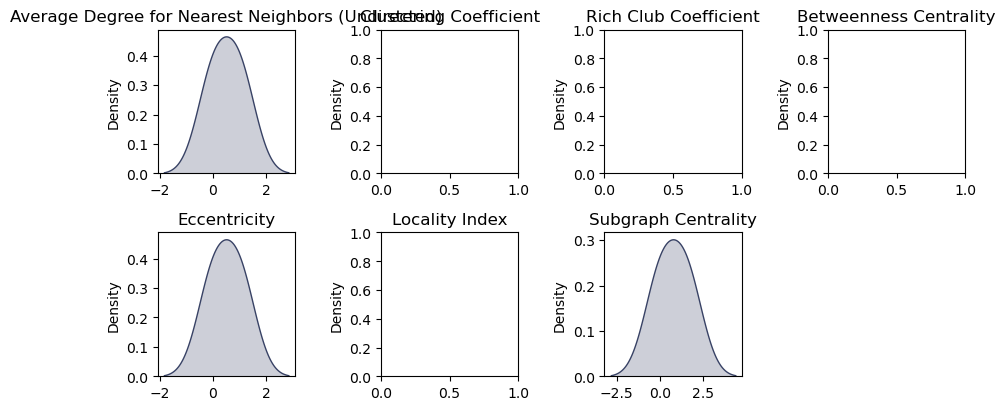

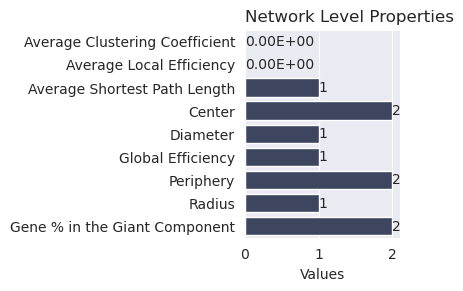

In [17]:
import networkx as nx
G = nx.Graph()
G.add_edge(1,2)
characterize_network(G, name='prueba')

`!!!!AGUAS!!!!`

In [18]:
compare_structure(networks, norm='biological', workers='auto')

Properties used for analysis: 
Average Clustering Coefficient
Average Degree for Nearest Neighbors (Undirected)
Average Local Efficiency
Average Degree for Nearest Neighbors (Out-Out)
Average Shortest Path Length
Betweenness Centrality
Center
Clustering Coefficient
Complex Feed-Forward Circuits
Density
Diameter
Eccentricity
Entropy of Degree Distribution
3-Feedback Loops
Gene % in the Giant Component
Gini Index
Global Efficiency
In-Degree
Locality Index
Max In-Dregree
Max Out-Degree
Out-Degree
Periphery
Radius
Regulators
Rich Club Coefficient
Self-Regulations
Subgraph Centrality




  0%|          | 0/7 [00:00<?, ?it/s]

Running aortic adventitial fibroblast
Running B-cells (CD20+)
Running Hematopoietic stem/progenitor cells (CD34+)
Running fetal brain
Running fetal heart
Running BA_aortic adventitial fibroblast_1
Running ER_aortic adventitial fibroblast_1
Running BA_B-cells (CD20+)_1
Running ER_B-cells (CD20+)_1
Running BA_Hematopoietic stem/progenitor cells (CD34+)_1
Running ER_Hematopoietic stem/progenitor cells (CD34+)_1
Running BA_fetal brain_1
Running ER_fetal brain_1
Running BA_fetal heart_1
Running ER_fetal heart_1


15it [00:49,  3.33s/it]                      


ValueError: operands could not be broadcast together with shapes (2,) (11,) 